In [83]:
import os
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# ── PyTorch core ──────────────────────────────────────────────────────────────
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torch

# ── TorchVision ───────────────────────────────────────────────────────────────
import torchvision.transforms.v2 as v2
from torchvision.models import inception_v3,resnet50,efficientnet_b4,EfficientNet_B4_Weights,ResNet50_Weights,Inception_V3_Weights
from torchvision.datasets import ImageFolder
from torchvision.utils import make_grid

# ── Data utilities ────────────────────────────────────────────────────────────
# from torch.utils.data import random_split
from torch.utils.data.dataloader import DataLoader
from sklearn.utils import shuffle
from tqdm import tqdm                                       # progress bars for training loop

# ── Evaluation ────────────────────────────────────────────────────────────────
from sklearn.metrics import confusion_matrix, classification_report,f1_score,roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [ ]:

TRAIN_PATH = r"C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\Deep Learning\CNN\All Data About CNN\mrl-eye-dataset\train"
VAL_PATH = r"C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\Deep Learning\CNN\All Data About CNN\mrl-eye-dataset\val"
TEST_PATH = r"C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\Deep Learning\CNN\All Data About CNN\mrl-eye-dataset\test"

SIZE = 224


BATCH_SIZE = 128
EPOCHS = 30
PATIENCE = 5

LR  = 1e-4


In [10]:
def show_all_images_counts(all_path:list):
    all_images_counts={}
    for path in all_path:
        labels = os.listdir(path)
        img_counts={}

        for label_name in labels:
            label_path = os.path.join(path, label_name)
            img_counts[label_name] = len(os.listdir(label_path))

        all_images_counts[path.split("\\")[-1]] = img_counts
    
    return all_images_counts

all_counts = show_all_images_counts([TRAIN_PATH,VAL_PATH,TEST_PATH])

In [11]:
print(f"All Images Counts In Train: {all_counts["train"]}\n")
print(f"All Images Counts In Val: {all_counts["val"]}\n")
print(f"All Images Counts In Test: {all_counts["test"]}\n")

All Images Counts In Train: {'awake': 25770, 'sleepy': 25167}

All Images Counts In Val: {'awake': 8591, 'sleepy': 8389}

All Images Counts In Test: {'awake': 8591, 'sleepy': 8390}



In [ ]:
def show_all_sizes(all_path:list):
    all_sizes={}
    for path in all_path:
        labels = os.listdir(path)
        sizes=[]

        for label_name in labels:
            label_path = os.path.join(path, label_name)
            images = os.listdir(label_path)
            for img in images:
                sizes.append(plt.imread(os.path.join(label_path,img)).shape)
            
        
        all_sizes[path.split("\\")[-1]] = set(sizes)
    
    return all_sizes

all_sizes = show_all_sizes([TRAIN_PATH,VAL_PATH,TEST_PATH])

In [ ]:
print(f"All Sizes In Train: {all_sizes["train"]}\n Value Counts: {len(all_sizes["train"])}\n")
print(f"All Sizes In Val: {all_sizes["val"]}\n Value Counts: {len(all_sizes["val"])}\n")
print(f"All Sizes In Test: {all_sizes["test"]}\n Value Counts: {len(all_sizes["test"])}\n")

All Sizes In Train: {(267, 267), (84, 84), (277, 277), (116, 116), (61, 61), (126, 126), (181, 181), (272, 272), (176, 176), (153, 153), (208, 208), (218, 218), (57, 57), (122, 122), (117, 117), (94, 94), (149, 149), (214, 214), (209, 209), (241, 241), (58, 58), (90, 90), (246, 246), (150, 150), (127, 127), (182, 182), (242, 242), (297, 297), (274, 274), (91, 91), (68, 68), (123, 123), (63, 63), (183, 183), (238, 238), (160, 160), (215, 215), (64, 64), (220, 220), (59, 59), (124, 124), (101, 101), (156, 156), (216, 216), (248, 248), (65, 65), (97, 97), (253, 253), (92, 92), (157, 157), (212, 212), (189, 189), (184, 184), (194, 194), (88, 88), (98, 98), (286, 286), (70, 70), (125, 125), (180, 180), (190, 190), (245, 245), (222, 222), (217, 217), (227, 227), (121, 121), (66, 66), (282, 282), (131, 131), (186, 186), (158, 158), (213, 213), (223, 223), (62, 62), (278, 278), (72, 72), (250, 250), (260, 260), (99, 99), (154, 154), (164, 164), (219, 219), (159, 159), (191, 191), (256, 256), (

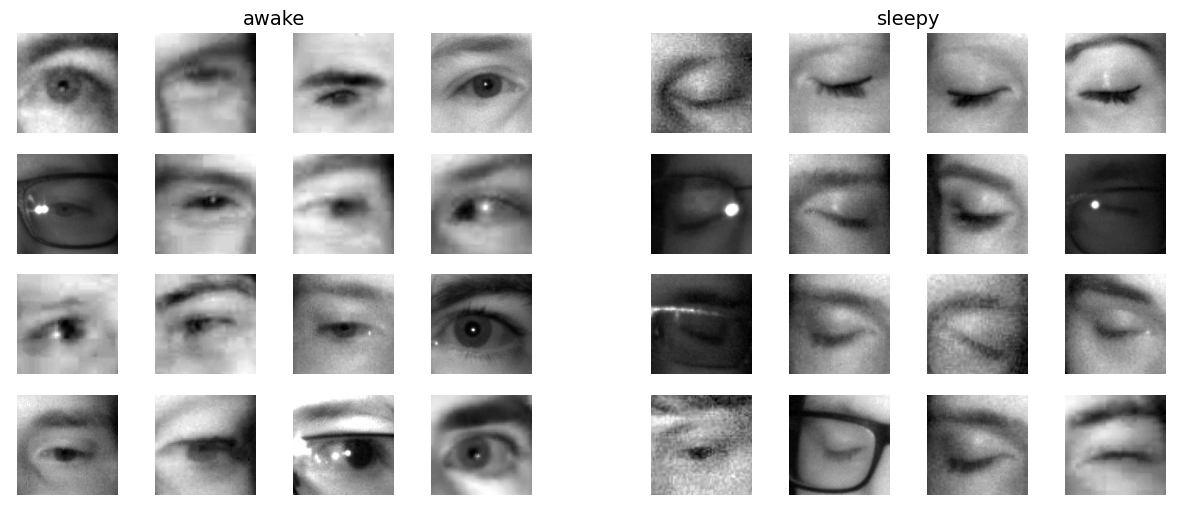

In [3]:
def show_random_image(PATH, num_of_samples=16):
    labels = os.listdir(PATH)

    fig = plt.figure(figsize=(15, 6))

    
    outer = fig.add_gridspec(1, 2, wspace=0.2)

    for j, label_name in enumerate(labels[:2]):
        label_path = os.path.join(PATH, label_name)
        images = shuffle(os.listdir(label_path))[:num_of_samples]

        
        inner = outer[j].subgridspec(4, 4)

        
        ax_title = fig.add_subplot(outer[j])
        ax_title.set_title(label_name, fontsize=14)
        ax_title.axis("off")

        for i, img_name in enumerate(images):
            r, c = divmod(i, 4)
            ax = fig.add_subplot(inner[r, c])
            img_path = os.path.join(label_path, img_name)
            ax.imshow(plt.imread(img_path), cmap="gray")
            ax.axis("off")

    plt.show()

show_random_image(TRAIN_PATH)

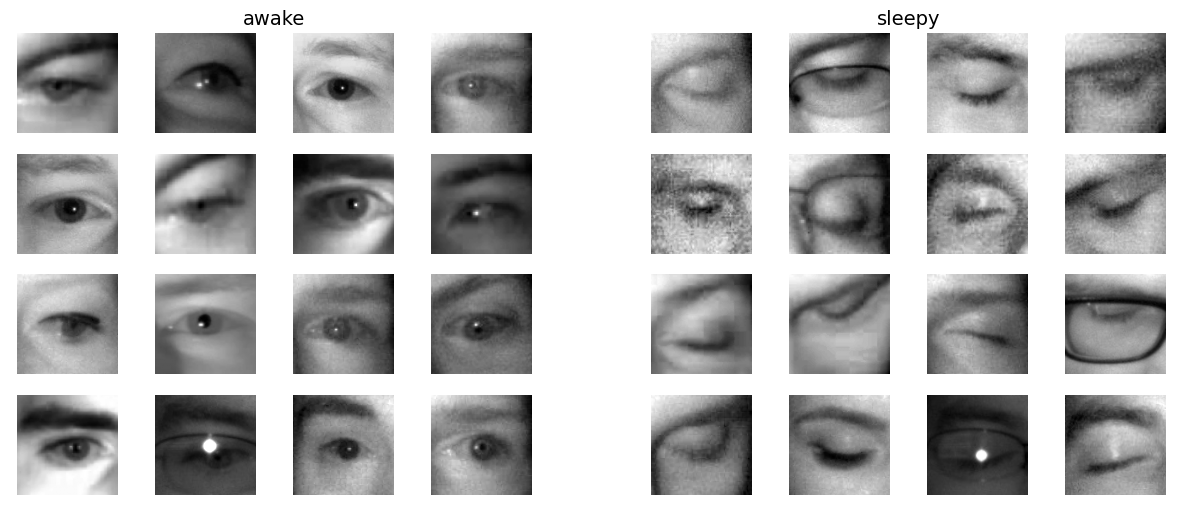

In [4]:
show_random_image(VAL_PATH)

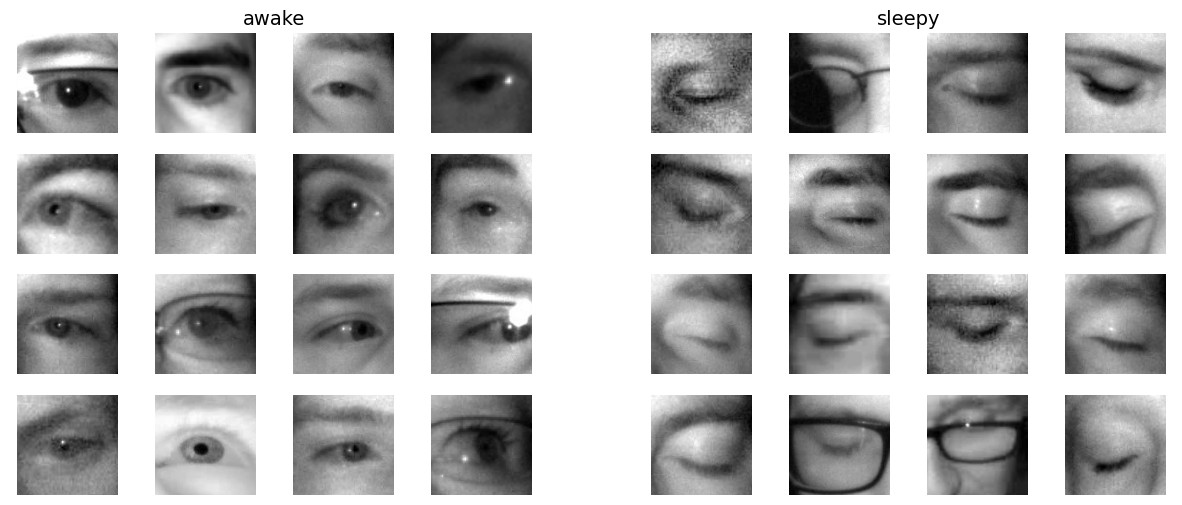

In [5]:
show_random_image(TEST_PATH)

In [78]:
def get_transforms(size=SIZE,apply_on_train=False):
    if apply_on_train:
        return v2.Compose([v2.Resize((size,size)),
                                   v2.ToImage(),
                                   v2.ToDtype(torch.float32, scale=True), 
                                   
                                #    v2.GaussianBlur(kernel_size=3, sigma=(0.1, 0.5)),
                                   v2.ColorJitter((0.8,1.3)),
                                   v2.RandomHorizontalFlip(),
                                   v2.RandomRotation(30),
                                   v2.GaussianNoise(),
                                   v2.Grayscale(),
                                   
                                   v2.Normalize((0.5,), (0.5,)),
                                   ])
    else:
        return v2.Compose([v2.Resize((size,size)),
                                   v2.ToImage(),
                                   v2.ToDtype(torch.float32, scale=True), 
                                   v2.Normalize((0.5,), (0.5,)),
                                   ])

In [79]:
def prepare_dataloader(train_p,val_p,test_p,img_size=SIZE,batch_size=BATCH_SIZE):
    train_df = ImageFolder(train_p,get_transforms(img_size,True))
    val_df = ImageFolder(val_p,get_transforms(img_size))
    test_df = ImageFolder(test_p,get_transforms(img_size))

    print("Train length: ",len(train_df))
    print("Validation length: ",len(val_df))
    print("Test length: ",len(test_df))

    train_dl = DataLoader(train_df,batch_size,True,num_workers=0,pin_memory=True)
    val_dl = DataLoader(val_df,batch_size,False,num_workers=0,pin_memory=True)
    test_dl = DataLoader(test_df,batch_size,False,num_workers=0,pin_memory=True)

    print("The Data Is Succssfuly Loaded...!")
    return (train_dl,val_dl,test_dl)

In [80]:
train,val,test = prepare_dataloader(TRAIN_PATH,VAL_PATH,TEST_PATH)

Train length:  50937
Validation length:  16980
Test length:  16981
The Data Is Succssfuly Loaded...!


In [81]:
def denorm(imgs):
    return (imgs + 1) / 2

(np.float64(-0.5), np.float64(3617.5), np.float64(905.5), np.float64(-0.5))

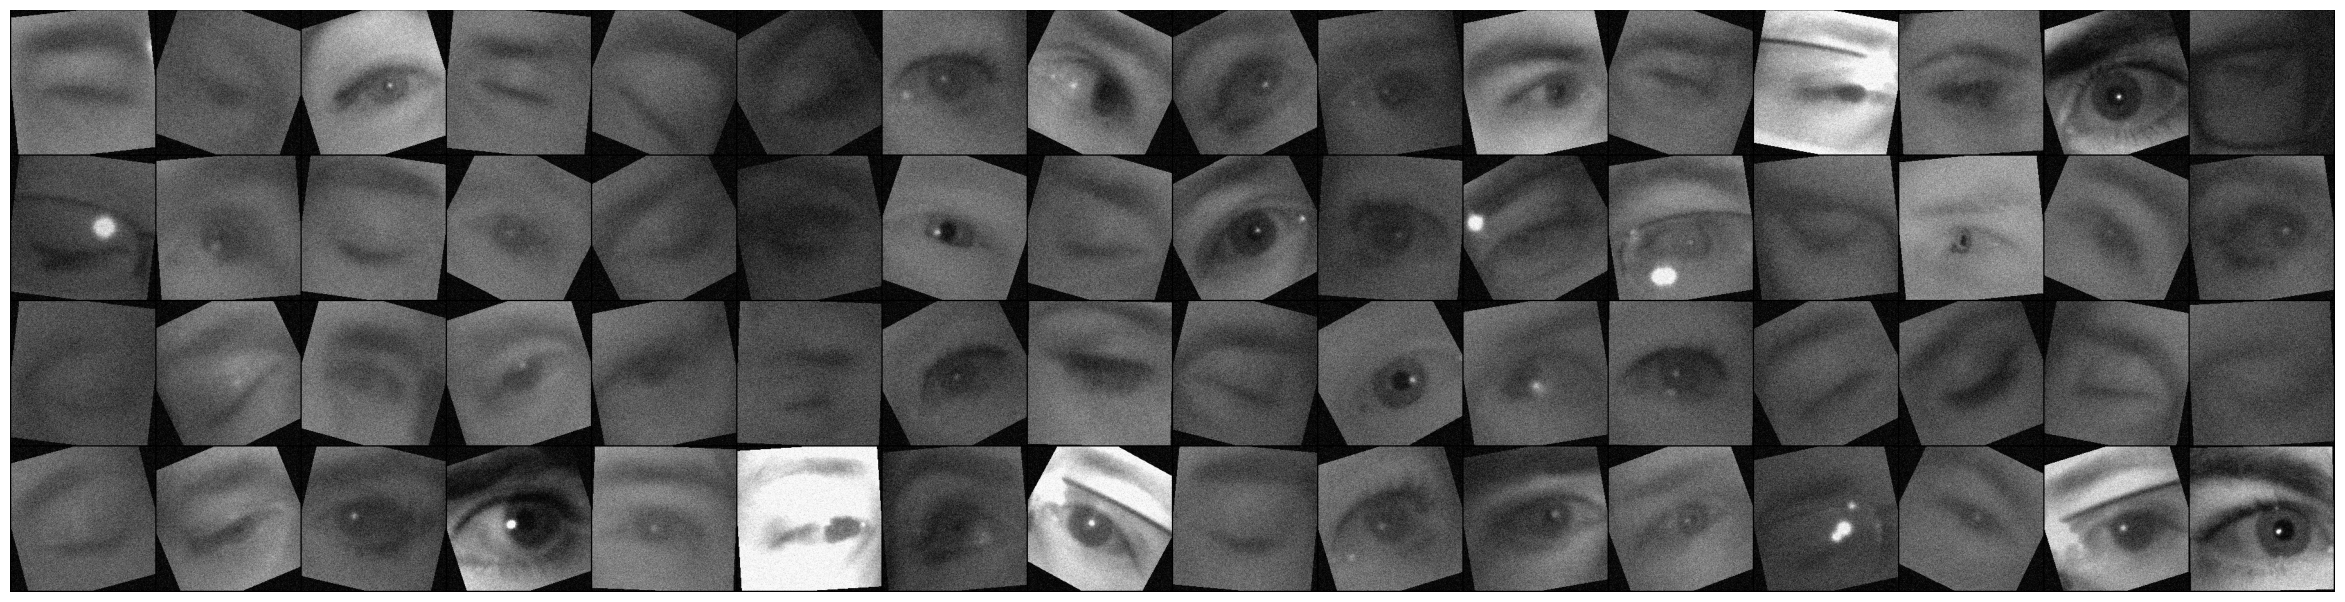

In [82]:
imgs,labels = next(iter(train))
plt.figure(figsize=(30, 30))

plt.imshow(make_grid(denorm(imgs),16).permute(1,2,0),cmap="gray")
plt.axis("off")

In [ ]:
def replace_classifier(model, name):
    """
    Replace the final classification layer for any supported architecture.

    Supported: EfficientNet, Inception, ResNet

    Parameters
    ----------
    model : pretrained PyTorch model
    name  : str — model class name used to identify architecture type

    Returns
    -------
    model with replaced classifier
    """


    if "Inception" in name:
        model.classifier  =nn.Linear(model.classifier.in_features, 2)
        

    elif "ResNet" in name:
        model.fc = nn.Linear(model.fc.in_features, 2)


    elif "EfficientNet" in name:
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)



    return model

In [ ]:
def build_model(model_name,weights="DEFAULT",learning_rate=LR):
    model = model_name(weights=weights)
    name = model.__class__.__name__
    model = replace_classifier(model,name)
    model = model.to(device)

    criterion = F.binary_cross_entropy()
    
    optimizer = optim.AdamW(model.parameters(),lr=learning_rate)
    
    return (model , criterion , optimizer)
    